# Setup

In [1]:
from statasetup import *


  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      StataNow 19.5
___/   /   /___/   /   /___/       BE—Basic Edition

 Statistics and Data Science       Copyright 1985-2025 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-782-8272        https://www.stata.com
                                   979-696-4600        service@stata.com

Stata license: Unlimited-user network, expiring 17 Sep 2027
Serial number: 301909300944
  Licensed to: StataNow/BE 19.5
               TU/e

Notes:
      1. Unicode is supported; see help unicode_advice.


In [3]:
%%stata
use "Datasets\asg1\Stereotype_threat.dta",clear

# Between-Subjects Anova with contrast analysis follow up
Be the contrast analysis the desired post-hoc analysis technique one should always try to match a **1 by n** design, diverting a bit from the initial study design.

This is usually done by using `group`. Doing it so will result in a less comprehensive answer but efortless generation of **SScontrast**. 

**Furthermore, make sure that the arrangement of the factors within `groups(factor1 factor2)` is not done arbitrarily** so by displaying the table `table groups factor1 factor2`

## 1. Conduct ANOVA with grouped effects

In [53]:
%%stata
anova performance race##test_type


                         Number of obs =         20    R-squared     =  0.5160
                         Root MSE      =    2.91548    Adj R-squared =  0.4253

                  Source | Partial SS         df         MS        F    Prob>F
          ---------------+----------------------------------------------------
                   Model |        145          3   48.333333      5.69  0.0076
                         |
                    race |         20          1          20      2.35  0.1446
               test_type |         45          1          45      5.29  0.0352
          race#test_type |         80          1          80      9.41  0.0074
                         |
                Residual |        136         16         8.5  
          ---------------+----------------------------------------------------
                   Total |        281         19   14.789474  


In [39]:
%%stata
drop groups
egen groups = group(race test_type)
anova performance groups

* Ideally, SS_model must be calculated and stored in mata's memory right away to prevent its loss
mata
SSmodel = st_numscalar("e(mss)")
SSmodel
end



. drop groups

. egen groups = group(race test_type)

. anova performance groups

                         Number of obs =         20    R-squared     =  0.5160
                         Root MSE      =    2.91548    Adj R-squared =  0.4253

                  Source | Partial SS         df         MS        F    Prob>F
              -----------+----------------------------------------------------
                   Model |        145          3   48.333333      5.69  0.0076
                         |
                  groups |        145          3   48.333333      5.69  0.0076
                         |
                Residual |        136         16         8.5  
              -----------+----------------------------------------------------
                   Total |        281         19   14.789474  

. 
. * Ideally, SS_model must be calculated and stored in mata's memory right away
>  to prevent its loss
. mata
------------------------------------------------- mata (type end to e

In [ ]:
%%stata
margins race#test_type
marginsplot

This test down bellow is not to be interrpreted but rather the next one which is specifically focoused on the contrast weights

In [24]:
%%stata
matrix L =(3, 1/3, 1/3, 1/3, 0)
manova performance = groups



. matrix L =(3, 1/3, 1/3, 1/3, 0)

. manova performance = groups

                       Number of obs =         20

                       W = Wilks' lambda      L = Lawley-Hotelling trace
                       P = Pillai's trace     R = Roy's largest root

              Source | Statistic        df    F(df1,     df2) =   F   Prob>F
          -----------+-------------------------------------------------------
              groups |W   0.4840         3      3.0     16.0     5.69 0.0076 e
                     |P   0.5160                3.0     16.0     5.69 0.0076 e
                     |L   1.0662                3.0     16.0     5.69 0.0076 e
                     |R   1.0662                3.0     16.0     5.69 0.0076 e
                     |-------------------------------------------------------
            Residual |                  16
          -----------+-------------------------------------------------------
               Total |                  19
          ----------------

In [ ]:
%%stata
manovatest, test(L)

* Same as before but for this time the contrast makes the item to be stored
mata
SScontrast = st_matrix("r(H)")
SScontrast
end


. manovatest, test(L)

 Test constraint
 (1)    3*1.groups + .3333333*2.groups + .3333333*3.groups + .3333333*4.groups
        = 0

                       W = Wilks' lambda      L = Lawley-Hotelling trace
                       P = Pillai's trace     R = Roy's largest root

              Source | Statistic        df    F(df1,     df2) =   F   Prob>F
          -----------+-------------------------------------------------------
          manovatest |W   0.5018         1      1.0     16.0    15.88 0.0011 e
                     |P   0.4982                1.0     16.0    15.88 0.0011 e
                     |L   0.9926                1.0     16.0    15.88 0.0011 e
                     |R   0.9926                1.0     16.0    15.88 0.0011 e
                     |-------------------------------------------------------
            Residual |                  16
          -------------------------------------------------------------------
                       e = exact, a = approximate, u =

## 2. Calculate eta alerting
**All the aforementioned steps must have been taken in order to have mata script able to calculate eta2alertin correctly**

In [41]:
%%stata

mean performance, over(groups)

// finally use mata to calculate the C-estimate and the eta squared alerting
mata
Means = st_matrix("e(b)")
L = st_matrix("L") 
Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means) 	  
Cest	
Eta2alerting = SScontrast/SSmodel
Eta2alerting				
end


. 
. mean performance, over(groups)

Mean estimation                                     Number of obs = 20

----------------------------------------------------------------------
                     |       Mean   Std. err.     [95% conf. interval]
---------------------+------------------------------------------------
c.performance@groups |
                  1  |          4    1.30384      1.271031    6.728969
                  2  |         11    1.30384      8.271031    13.72897
                  3  |         10    1.30384      7.271031    12.72897
                  4  |          9    1.30384      6.271031    11.72897
----------------------------------------------------------------------

. 
. // finally use mata to calculate the C-estimate and the eta squared alerting
. mata
------------------------------------------------- mata (type end to exit) -----
: Means = st_matrix("e(b)")

: L = st_matrix("L") 

: Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means)     

: Cest    
  22

: Eta2

## 3. Conduct post-hoc planned comparisons by partialling out population groups

**Furthermore, make sure that the arrangement of the factors within `groups(factor1 factor2)` is not done arbitrarily** so by displaying the table `table groups factor1 factor2`

In [35]:
%%stata
drop groups
egen groups = group(test_type race)
table test_type race
anova performance groups 

* Ideally, SS_model must be calculated and stored in mata's memory right away to prevent its loss
mata
SSmodel = st_numscalar("e(mss)")
SSmodel
end

matrix L1=[1,0,-1,0,0]
manova performance=groups
manovatest, test(L1)

mean performance, over(groups)

// finally use mata to calculate the C-estimate and the eta squared alerting
mata
Means = st_matrix("e(b)")
L = st_matrix("L1") 
Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means) 	  
Cest	
Eta2alerting = SScontrast/SSmodel
Eta2alerting				
end


. drop groups

. egen groups = group(test_type race)

. table test_type race

-----------------------------------------
                 |           race        
                 |  black   white   Total
-----------------+-----------------------
test_type        |                       
  diagnostic     |      5       5      10
  non-diagnostic |      5       5      10
  Total          |     10      10      20
-----------------------------------------

. anova performance groups 

                         Number of obs =         20    R-squared     =  0.5160
                         Root MSE      =    2.91548    Adj R-squared =  0.4253

                  Source | Partial SS         df         MS        F    Prob>F
              -----------+----------------------------------------------------
                   Model |        145          3   48.333333      5.69  0.0076
                         |
                  groups |        145          3   48.333333      5.69  0.0076
           


Mean estimation                                     Number of obs = 20

----------------------------------------------------------------------
                     |       Mean   Std. err.     [95% conf. interval]
---------------------+------------------------------------------------
c.performance@groups |
                  1  |          4    1.30384      1.271031    6.728969
                  2  |         10    1.30384      7.271031    12.72897
                  3  |         11    1.30384      8.271031    13.72897
                  4  |          9    1.30384      6.271031    11.72897
----------------------------------------------------------------------

. 
. // finally use mata to calculate the C-estimate and the eta squared alerting
. mata
------------------------------------------------- mata (type end to exit) -----
: Means = st_matrix("e(b)")

: L = st_matrix("L1") 

: Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means)     

: Cest    
  -7

: Eta2alerting = SScontrast/SSmodel

: Eta

In [34]:
%%stata
matrix L1=[1,-1,0,0,0]
manova performance=groups
manovatest, test(L1)

mean performance, over(groups)

// finally use mata to calculate the C-estimate and the eta squared alerting
mata
Means = st_matrix("e(b)")
L = st_matrix("L1") 
Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means) 	  
Cest	
Eta2alerting = SScontrast/SSmodel
Eta2alerting				
end


. matrix L1=[1,-1,0,0,0]

. manova performance=groups

                       Number of obs =         20

                       W = Wilks' lambda      L = Lawley-Hotelling trace
                       P = Pillai's trace     R = Roy's largest root

              Source | Statistic        df    F(df1,     df2) =   F   Prob>F
          -----------+-------------------------------------------------------
              groups |W   0.4840         3      3.0     16.0     5.69 0.0076 e
                     |P   0.5160                3.0     16.0     5.69 0.0076 e
                     |L   1.0662                3.0     16.0     5.69 0.0076 e
                     |R   1.0662                3.0     16.0     5.69 0.0076 e
                     |-------------------------------------------------------
            Residual |                  16
          -----------+-------------------------------------------------------
               Total |                  19
          ---------------------------


Mean estimation                                     Number of obs = 20

----------------------------------------------------------------------
                     |       Mean   Std. err.     [95% conf. interval]
---------------------+------------------------------------------------
c.performance@groups |
                  1  |          4    1.30384      1.271031    6.728969
                  2  |         10    1.30384      7.271031    12.72897
                  3  |         11    1.30384      8.271031    13.72897
                  4  |          9    1.30384      6.271031    11.72897
----------------------------------------------------------------------

. 
. // finally use mata to calculate the C-estimate and the eta squared alerting
. mata
------------------------------------------------- mata (type end to exit) -----
: Means = st_matrix("e(b)")

: L = st_matrix("L1") 

: Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means)     

: Cest    
  -6

: Eta2alerting = SScontrast/SSmodel

: Eta

In [36]:
%%stata
matrix L1=[1,0,0,-1,0]
manova performance=groups
manovatest, test(L1)

mean performance, over(groups)

// finally use mata to calculate the C-estimate and the eta squared alerting
mata
Means = st_matrix("e(b)")
L = st_matrix("L1") 
Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means) 	  
Cest	
Eta2alerting = SScontrast/SSmodel
Eta2alerting				
end


. matrix L1=[1,0,0,-1,0]

. manova performance=groups

                       Number of obs =         20

                       W = Wilks' lambda      L = Lawley-Hotelling trace
                       P = Pillai's trace     R = Roy's largest root

              Source | Statistic        df    F(df1,     df2) =   F   Prob>F
          -----------+-------------------------------------------------------
              groups |W   0.4840         3      3.0     16.0     5.69 0.0076 e
                     |P   0.5160                3.0     16.0     5.69 0.0076 e
                     |L   1.0662                3.0     16.0     5.69 0.0076 e
                     |R   1.0662                3.0     16.0     5.69 0.0076 e
                     |-------------------------------------------------------
            Residual |                  16
          -----------+-------------------------------------------------------
               Total |                  19
          ---------------------------

## 4. Orthogonality discovery

In [43]:
#TODO Incorporate some images

In [37]:
%%stata
use "Datasets\asg1\Therapy.dta",clear

## 4.1 Calculation of the maxium variance/`SS_model` based on three contrasts (two main and one interaction)

In [49]:
%%stata
drop groups
egen groups = group(gender_therapist gender_client)
mean gender_therapist gender_client
anova efficiency groups

* Ideally, SS_model must be calculated and stored in mata's memory right away to prevent its loss
mata
SSmodel = st_numscalar("e(mss)")
SSmodel
end


. drop groups

. egen groups = group(gender_therapist gender_client)

. mean gender_therapist gender_client



Mean estimation                                 Number of obs = 20

------------------------------------------------------------------
                 |       Mean   Std. err.     [95% conf. interval]
-----------------+------------------------------------------------
gender_therapist |        1.5   .1147079      1.259914    1.740086
   gender_client |        1.5   .1147079      1.259914    1.740086
------------------------------------------------------------------

. anova efficiency groups

                         Number of obs =         20    R-squared     =  0.5160
                         Root MSE      =    2.91548    Adj R-squared =  0.4253

                  Source | Partial SS         df         MS        F    Prob>F
              -----------+----------------------------------------------------
                   Model |        145          3   48.333333      5.69  0.0076
                         |
                  groups |        145          3   48.333333      5.69  0.0076

## 4.2 Run contrast analyses for each contrast weight independently
This is done in order to obtain the so corresponding set of  `SS_contrast`(s) and determine if `SS_contrast1 + SS_contrast2 ... + SS_c_n >= SS_contrast1_contrast2_contrast3` 

### The main effects

In [ ]:
%%stata
matrix L1 = (1/2,1/2,-1/2,-1/2,0)
matrix L2 = (1/2,-1/2,1/2,-1/2,0)

manova efficiency=groups
manovatest, test(L1)

* Same as before but for this time the contrast makes the item to be stored
mata
SScontrast = st_matrix("r(H)")
SScontrast
end

mean efficiency, over(groups)

// finally use mata to calculate the C-estimate and the eta squared alerting
mata
Means = st_matrix("e(b)")
L = st_matrix("L1") 
Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means) 	  
Cest	
Eta2alerting = SScontrast/SSmodel
Eta2alerting				
end


manova efficiency=groups
manovatest, test(L2)

* Same as before but for this time the contrast makes the item to be stored
mata
SScontrast = st_matrix("r(H)")
SScontrast
end

mean efficiency, over(groups)

// finally use mata to calculate the C-estimate and the eta squared alerting
mata
Means = st_matrix("e(b)")
L = st_matrix("L2") 
Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means) 	  
Cest	
Eta2alerting = SScontrast/SSmodel
Eta2alerting				
end


. matrix L1 = (1/2,1/2,-1/2,-1/2,0)

. matrix L2 = (1/2,-1/2,1/2,-1/2,0)

. matrix L3 = (1,-1,1,-1,0)

. 
. manova efficiency=groups

                       Number of obs =         20

                       W = Wilks' lambda      L = Lawley-Hotelling trace
                       P = Pillai's trace     R = Roy's largest root

              Source | Statistic        df    F(df1,     df2) =   F   Prob>F
          -----------+-------------------------------------------------------
              groups |W   0.4840         3      3.0     16.0     5.69 0.0076 e
                     |P   0.5160                3.0     16.0     5.69 0.0076 e
                     |L   1.0662                3.0     16.0     5.69 0.0076 e
                     |R   1.0662                3.0     16.0     5.69 0.0076 e
                     |-------------------------------------------------------
            Residual |                  16
          -----------+-------------------------------------------------------
 


Mean estimation                                    Number of obs = 20

---------------------------------------------------------------------
                    |       Mean   Std. err.     [95% conf. interval]
--------------------+------------------------------------------------
c.efficiency@groups |
                 1  |          4    1.30384      1.271031    6.728969
                 2  |         10    1.30384      7.271031    12.72897
                 3  |         11    1.30384      8.271031    13.72897
                 4  |          9    1.30384      6.271031    11.72897
---------------------------------------------------------------------

. 
. // finally use mata to calculate the C-estimate and the eta squared alerting
. mata
------------------------------------------------- mata (type end to exit) -----
: Means = st_matrix("e(b)")

: L = st_matrix("L2") 

: Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means)     

: Cest    
  -2

: Eta2alerting = SScontrast/SSmodel

: Eta2alerting 

### The interaction effect

In [60]:
%%stata
matrix L3 = (1,-1,1,-1,0)

manova efficiency=groups
manovatest, test(L3)


* Same as before but for this time the contrast makes the item to be stored
mata
SScontrast = st_matrix("r(H)")
SScontrast
end

mean efficiency, over(groups)

// finally use mata to calculate the C-estimate and the eta squared alerting
mata
Means = st_matrix("e(b)")
L = st_matrix("L3") 
Cest = rowsum(L[1,1::(cols(L) - 1)] :* Means) 	  
Cest	
Eta2alerting = SScontrast/SSmodel
Eta2alerting				
end



. matrix L3 = (1,-1,1,-1,0)

. 
. manova efficiency=groups

                       Number of obs =         20

                       W = Wilks' lambda      L = Lawley-Hotelling trace
                       P = Pillai's trace     R = Roy's largest root

              Source | Statistic        df    F(df1,     df2) =   F   Prob>F
          -----------+-------------------------------------------------------
              groups |W   0.4840         3      3.0     16.0     5.69 0.0076 e
                     |P   0.5160                3.0     16.0     5.69 0.0076 e
                     |L   1.0662                3.0     16.0     5.69 0.0076 e
                     |R   1.0662                3.0     16.0     5.69 0.0076 e
                     |-------------------------------------------------------
            Residual |                  16
          -----------+-------------------------------------------------------
               Total |                  19
          ----------------------

## 4.3 Confirm the independence of contrast analyses

There are a few avenues one could walk down in order to confirm or refute independence between multiple planned theories.
1. The first method concerns summation of all `SScontrast` associated to the main effects that must yield a result equal/equivalent with the `SScontrast` computed based on the interaction effect or all theories clustered together. 

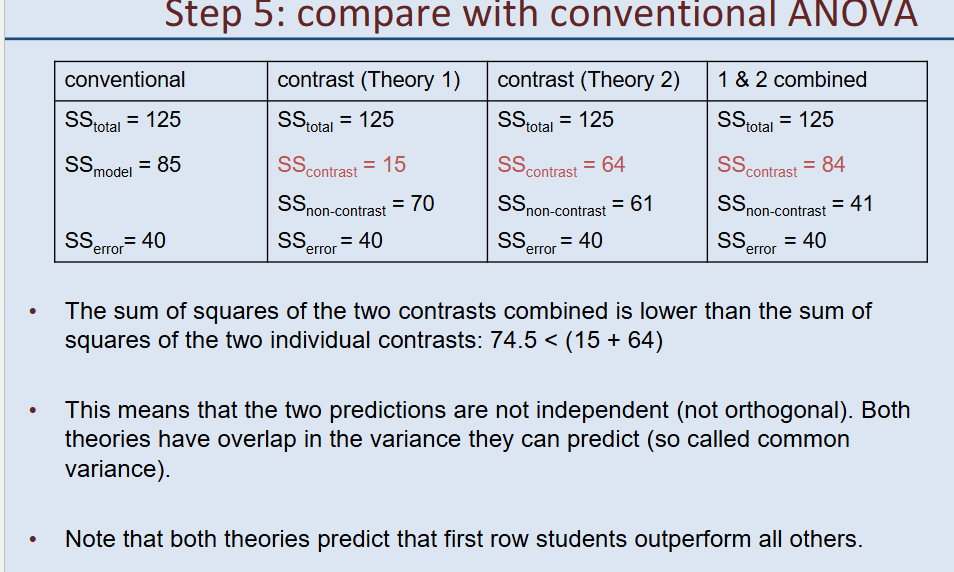

2. Second is rather a sophisticated approach where all observed contrasts schemes must be multiplied with each other. More specifically, their respective weight schemes must return zero regardless of the contrast underlying nature (main or interaction effect)

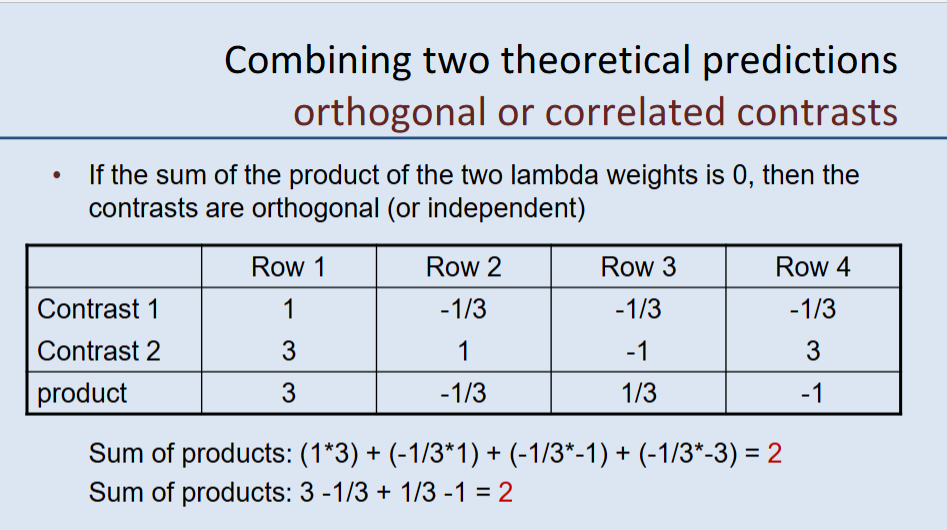